![Futurystyczny elektryczny samochód podczas ładowania](ev_charging.png)

Amerykańskie Alternative Fuels Data Center gromadzi dane o infrastrukturze ładowania pojazdów elektrycznych (EV), w tym o portach ładowania i lokalizacjach stacji, a także o sprzedaży pojazdów elektrycznych. Przy szybko rozwijającym się rynku EV zrozumienie trendów w punktach ładowania i sprzedaży jest kluczowe dla planowania strategicznego.

Jako data scientist u wiodącego operatora sieci ładowania EV widzisz potencjał w tych danych i zaczynasz porządkować oraz wizualizować zagregowane dane roczne.

Te roczne dane, zebrane w grudniu każdego roku, obejmują zapisy instalacji portów ładowania EV i lokalizacji stacji na przestrzeni około dziesięciu lat, uwzględniając zarówno środowiska ładowania publiczne, jak i prywatne.
___

### Dane
&nbsp;

`private_ev_charging.csv`

| Variable   | Description                                          |
|------------|------------------------------------------------------|
| `year` |  Rok zbierania danych |
| `private_ports`| Liczba dostępnych portów ładowania należących do firm prywatnych w danym roku |
| `private_station_locations`   | Liczba prywatnych lokalizacji stacji ładowania EV

___

`public_ev_charging.csv`
 
| Variable   | Description                                          |
|------------|------------------------------------------------------|
| `year` |  Rok zbierania danych  |
| `public_ports`| Liczba dostępnych portów ładowania w zasobach publicznych w danym roku  |
| `public_station_locations`   | Liczba publicznych lokalizacji stacji ładowania EV

___

Informacje o sprzedaży są dostępne dla każdego modelu i roku w pliku `ev_sales.csv`:

| Variable   | Description                                          |
|------------|------------------------------------------------------|
| `Vehicle` |  Model pojazdu elektrycznego |
| `year`| Rok zbierania danych |
| `sales`   | Liczba pojazdów sprzedanych w USA

In [30]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

361315.0


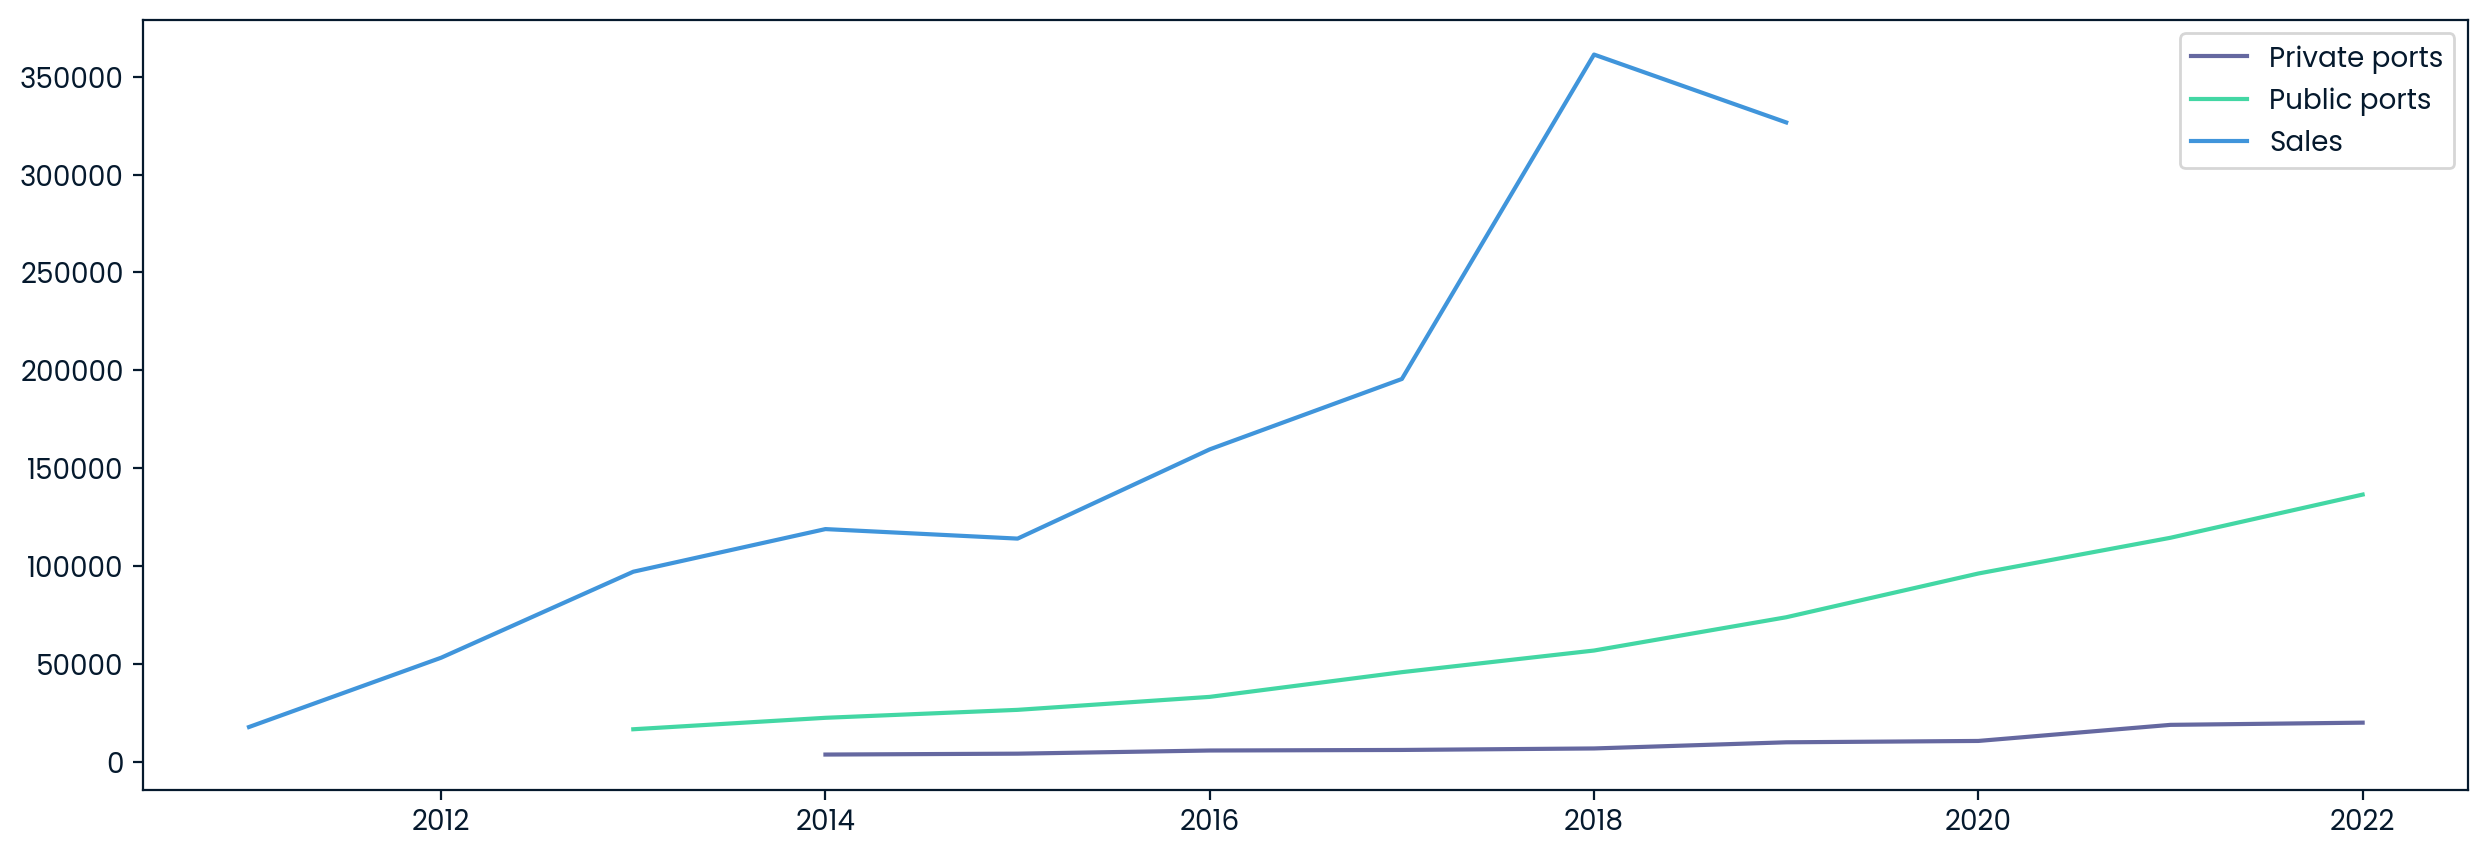

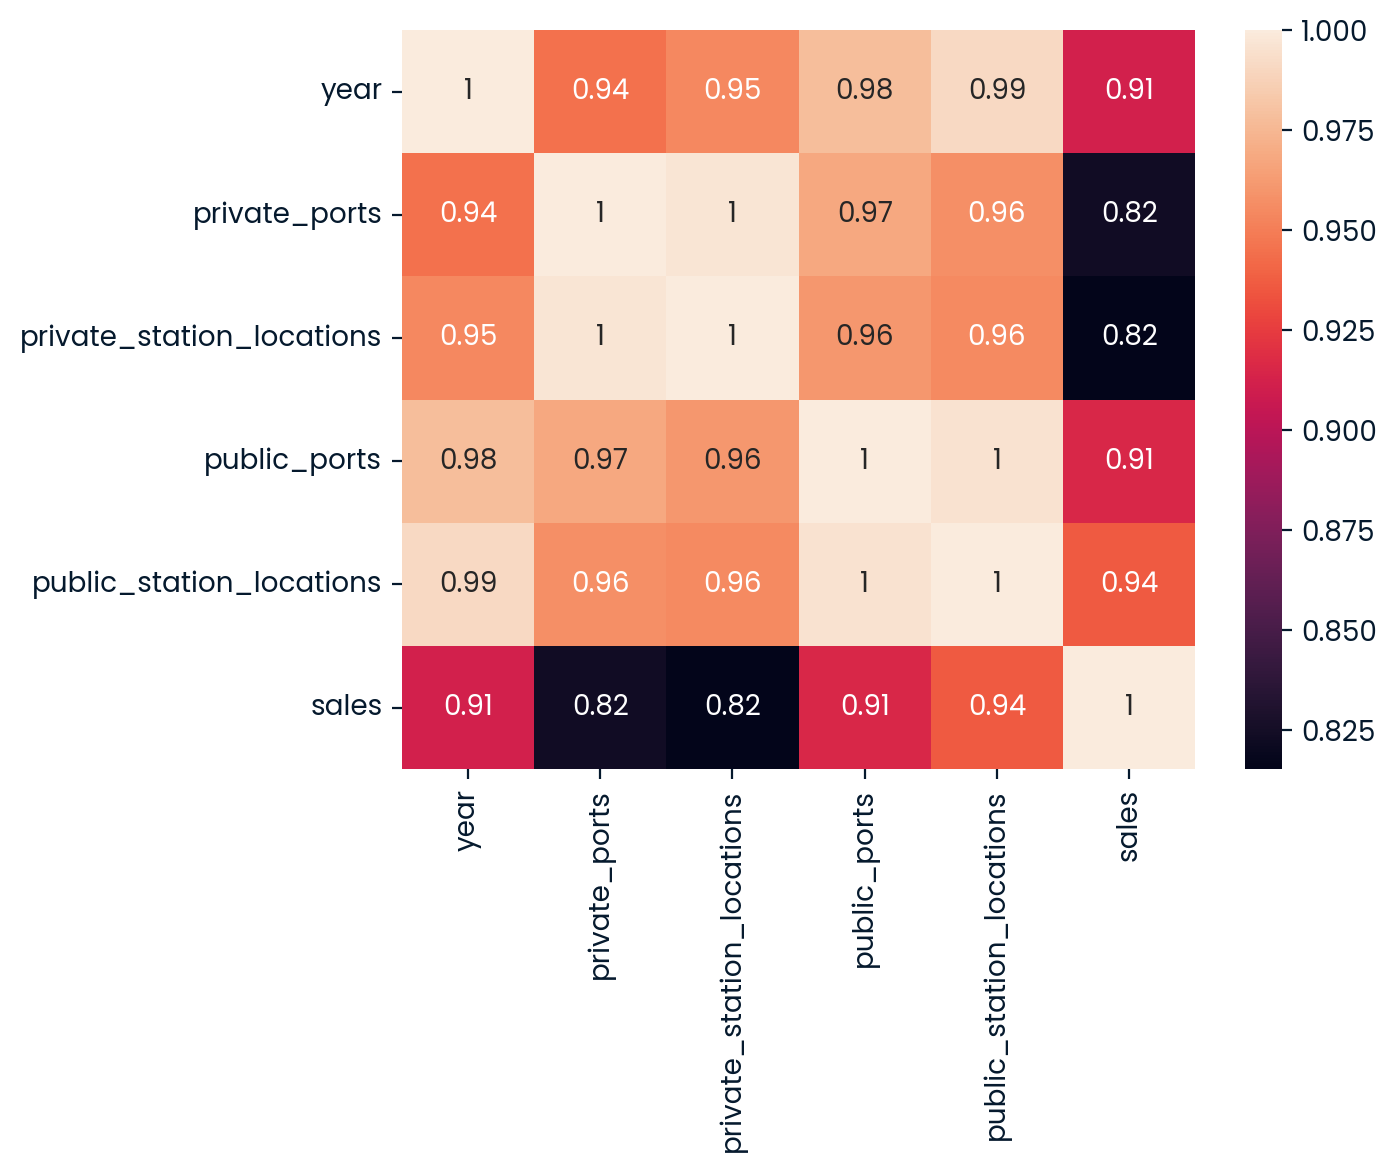

In [31]:
# Start coding here
private_ev_charging = pd.read_csv('private_ev_charging.csv')
public_ev_charging = pd.read_csv('public_ev_charging.csv')
ev_sales = pd.read_csv('ev_sales.csv')

#Ile pojazdów łącznie sprzedano w 2018 roku? 
ev_sales_2018 = ev_sales[ev_sales['year'] == 2018]['sales'].sum()
print(ev_sales_2018)

# suma sprzedaży według roku
sales = ev_sales.groupby("year", as_index=False)["sales"].sum()

#trendy
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(private_ev_charging["year"], private_ev_charging["private_ports"], label="Private ports")
ax.plot(public_ev_charging["year"], public_ev_charging["public_ports"], label="Public ports")
ax.plot(sales["year"], sales["sales"], label="Sales")
ax.legend()
plt.show()

#Czy sprzedaż pojazdów oraz liczba prywatnych i publicznych portów wykazywały ten sam trend (rosnący lub malejący) w latach 2015–2018?
ports = private_ev_charging.merge(public_ev_charging, on ='year')
data = ports.merge(sales, on = "year")

corr = data.corr()
sns.heatmap(corr, annot=True)
plt.show()

trend = "same"